In [1]:
import numpy as np
import pandas as pd
import matplotlib
import cv2
from PIL import Image
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OpenCV:", cv2.__version__)
print("Pillow:", Image.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
Matplotlib: 3.11.2
OpenCV: 5.0.0
Pillow: 12.3.0
Scikit-learn: 1.9.1


In [2]:
from pathlib import Path

# Project directories
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR /"Car_Color_Detection_AI"/ "data" / "raw"

print("Project directory:")
print(PROJECT_DIR)

print("\nRaw data directory:")
print(DATA_DIR)

print("\nContents:")
for item in DATA_DIR.iterdir():
    print(item.name)

Project directory:
c:\Users\hasibul shaikh\Documents

Raw data directory:
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw

Contents:
archive (6)
traffic_test.jpg


In [3]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    p for p in DATA_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Total images found:", len(images))

print("\nFirst 10 images:")
for image in images[:10]:
    print(image)

Total images found: 10374

First 10 images:
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\traffic_test.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\02e37c0e56.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\05aeb6ddec.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\0b01008bee.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\0c3bb456ee.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\0e491569c8.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\148b514638.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\1a1296c730.jpg
c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\test\beige\1aaaa2efd9.jpg
c:\Users\hasibul shaikh\Documents\Car_Col

In [4]:
folders = sorted({
    image.parent.name
    for image in images
})

print("Folders containing images:")
for folder in folders:
    print(folder)

Folders containing images:
beige
black
blue
brown
gold
green
grey
orange
pink
purple
raw
red
silver
tan
white
yellow


In [5]:
from collections import Counter

color_counts = Counter()

for image in images:
    color = image.parent.name
    color_counts[color] += 1

print("Images per class:\n")

for color, count in sorted(color_counts.items()):
    print(f"{color:15s} : {count}")

Images per class:

beige           : 601
black           : 579
blue            : 1060
brown           : 807
gold            : 300
green           : 804
grey            : 611
orange          : 762
pink            : 689
purple          : 765
raw             : 1
red             : 909
silver          : 516
tan             : 571
white           : 575
yellow          : 824


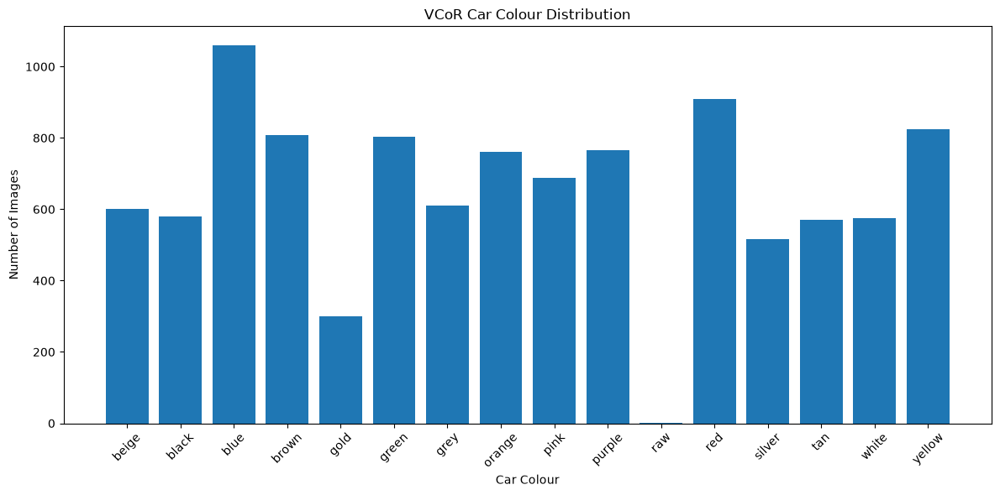

In [6]:
import matplotlib.pyplot as plt

colors = list(sorted(color_counts.keys()))
counts = [color_counts[c] for c in colors]

plt.figure(figsize=(12, 6))
plt.bar(colors, counts)

plt.xlabel("Car Colour")
plt.ylabel("Number of Images")
plt.title("VCoR Car Colour Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

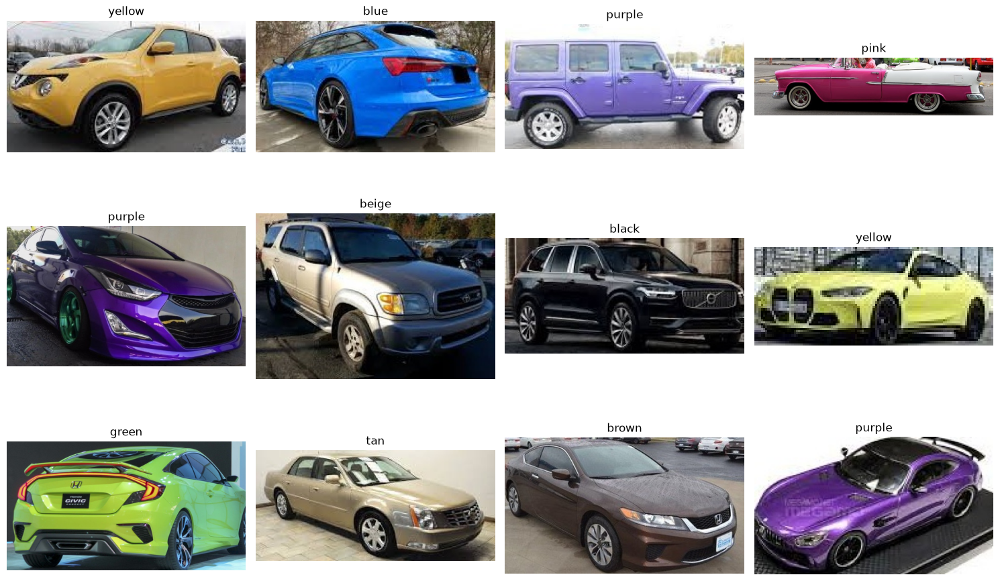

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_images = random.sample(images, min(12, len(images)))

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):
    img = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(image_path.parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
print("========== DATASET SUMMARY ==========")
print("Total images:", len(images))
print("Number of colour classes:", len(color_counts))

print("\nClasses:")
for color in sorted(color_counts):
    print("-", color)

========== DATASET SUMMARY ==========
Total images: 10374
Number of colour classes: 16

Classes:
- beige
- black
- blue
- brown
- gold
- green
- grey
- orange
- pink
- purple
- raw
- red
- silver
- tan
- white
- yellow


In [9]:
# Create sorted colour classes
class_names = sorted(color_counts.keys())

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

print("\nTotal classes:", len(class_names))

Classes:
0 -> beige
1 -> black
2 -> blue
3 -> brown
4 -> gold
5 -> green
6 -> grey
7 -> orange
8 -> pink
9 -> purple
10 -> raw
11 -> red
12 -> silver
13 -> tan
14 -> white
15 -> yellow

Total classes: 16


In [11]:
from PIL import Image
from pathlib import Path

valid_images = []
bad_images = []

for image_path in images:
    try:
        with Image.open(image_path) as img:
            img.verify()
        valid_images.append(image_path)
    except Exception:
        bad_images.append(image_path)

print("Total images :", len(images))
print("Valid images :", len(valid_images))
print("Bad images   :", len(bad_images))

Total images : 10374
Valid images : 10374
Bad images   : 0


In [12]:
from collections import Counter

sizes = Counter()

for image_path in valid_images:
    try:
        with Image.open(image_path) as img:
            sizes[img.size] += 1
    except:
        pass

print("Different image sizes:", len(sizes))

print("\nMost common sizes:")
for size, count in sizes.most_common(15):
    print(size, ":", count)

Different image sizes: 8616

Most common sizes:
(244, 122) : 6
(230, 94) : 5
(247, 145) : 5
(240, 120) : 5
(225, 137) : 5
(237, 103) : 5
(225, 109) : 5
(255, 164) : 5
(268, 125) : 5
(232, 123) : 5
(247, 127) : 5
(255, 142) : 5
(247, 150) : 5
(250, 127) : 5
(233, 123) : 5


In [13]:
clean_counts = Counter(image_path.parent.name for image_path in valid_images)

print("Class distribution:\n")

for class_name in class_names:
    print(f"{class_name:15s}: {clean_counts[class_name]}")

Class distribution:

beige          : 601
black          : 579
blue           : 1060
brown          : 807
gold           : 300
green          : 804
grey           : 611
orange         : 762
pink           : 689
purple         : 765
raw            : 1
red            : 909
silver         : 516
tan            : 571
white          : 575
yellow         : 824


In [30]:
from pathlib import Path

print("Dataset structure:\n")

for path in DATA_DIR.rglob("*"):
    if path.is_dir():
        print(path.relative_to(DATA_DIR))

Dataset structure:

archive (6)
archive (6)\test
archive (6)\train
archive (6)\val
archive (6)\test\beige
archive (6)\test\black
archive (6)\test\blue
archive (6)\test\brown
archive (6)\test\gold
archive (6)\test\green
archive (6)\test\grey
archive (6)\test\orange
archive (6)\test\pink
archive (6)\test\purple
archive (6)\test\red
archive (6)\test\silver
archive (6)\test\tan
archive (6)\test\white
archive (6)\test\yellow
archive (6)\train\beige
archive (6)\train\black
archive (6)\train\blue
archive (6)\train\brown
archive (6)\train\gold
archive (6)\train\green
archive (6)\train\grey
archive (6)\train\orange
archive (6)\train\pink
archive (6)\train\purple
archive (6)\train\red
archive (6)\train\silver
archive (6)\train\tan
archive (6)\train\white
archive (6)\train\yellow
archive (6)\val\beige
archive (6)\val\black
archive (6)\val\blue
archive (6)\val\brown
archive (6)\val\gold
archive (6)\val\green
archive (6)\val\grey
archive (6)\val\orange
archive (6)\val\pink
archive (6)\val\purple
ar

Image: c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\traffic_test.jpg
Size: (4640, 6960)
Mode: RGB
Label: raw


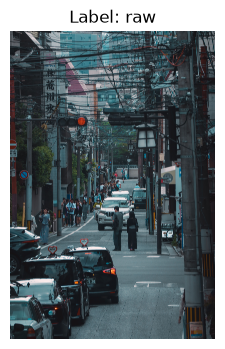

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

sample = valid_images[0]

img = Image.open(sample)

print("Image:", sample)
print("Size:", img.size)
print("Mode:", img.mode)
print("Label:", sample.parent.name)

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title(f"Label: {sample.parent.name}")
plt.axis("off")
plt.show()

In [41]:
print("DATASET STRUCTURE")
print("=" * 50)

for path in DATA_DIR.rglob("*"):
    if path.is_dir():
        print(path.relative_to(DATA_DIR))

DATASET STRUCTURE
archive (6)
archive (6)\test
archive (6)\train
archive (6)\val
archive (6)\test\beige
archive (6)\test\black
archive (6)\test\blue
archive (6)\test\brown
archive (6)\test\gold
archive (6)\test\green
archive (6)\test\grey
archive (6)\test\orange
archive (6)\test\pink
archive (6)\test\purple
archive (6)\test\red
archive (6)\test\silver
archive (6)\test\tan
archive (6)\test\white
archive (6)\test\yellow
archive (6)\train\beige
archive (6)\train\black
archive (6)\train\blue
archive (6)\train\brown
archive (6)\train\gold
archive (6)\train\green
archive (6)\train\grey
archive (6)\train\orange
archive (6)\train\pink
archive (6)\train\purple
archive (6)\train\red
archive (6)\train\silver
archive (6)\train\tan
archive (6)\train\white
archive (6)\train\yellow
archive (6)\val\beige
archive (6)\val\black
archive (6)\val\blue
archive (6)\val\brown
archive (6)\val\gold
archive (6)\val\green
archive (6)\val\grey
archive (6)\val\orange
archive (6)\val\pink
archive (6)\val\purple
arch

In [42]:
from pathlib import Path

print("DATASET STRUCTURE")
print("=" * 50)

for path in DATA_DIR.rglob("*"):
    if path.is_dir():
        print(path.relative_to(DATA_DIR))

DATASET STRUCTURE
archive (6)
archive (6)\test
archive (6)\train
archive (6)\val
archive (6)\test\beige
archive (6)\test\black
archive (6)\test\blue
archive (6)\test\brown
archive (6)\test\gold
archive (6)\test\green
archive (6)\test\grey
archive (6)\test\orange
archive (6)\test\pink
archive (6)\test\purple
archive (6)\test\red
archive (6)\test\silver
archive (6)\test\tan
archive (6)\test\white
archive (6)\test\yellow
archive (6)\train\beige
archive (6)\train\black
archive (6)\train\blue
archive (6)\train\brown
archive (6)\train\gold
archive (6)\train\green
archive (6)\train\grey
archive (6)\train\orange
archive (6)\train\pink
archive (6)\train\purple
archive (6)\train\red
archive (6)\train\silver
archive (6)\train\tan
archive (6)\train\white
archive (6)\train\yellow
archive (6)\val\beige
archive (6)\val\black
archive (6)\val\blue
archive (6)\val\brown
archive (6)\val\gold
archive (6)\val\green
archive (6)\val\grey
archive (6)\val\orange
archive (6)\val\pink
archive (6)\val\purple
arch

In [43]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
RAW_DIR = PROJECT_DIR / "Car_Color_Detection_AI" / "data" / "raw"

print("Project:", PROJECT_DIR)
print("Raw data:", RAW_DIR)
print()

# Show everything directly inside data/raw
print("=== DATA/RAW CONTENTS ===")
for item in RAW_DIR.iterdir():
    if item.is_dir():
        print("[FOLDER]", item.name)
    else:
        print("[FILE]  ", item.name)

# Find image files
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    p for p in RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("\n=== IMAGE INFORMATION ===")
print("Total images found:", len(images))

if images:
    print("\nFirst 20 images:")
    for p in images[:20]:
        print(p.relative_to(RAW_DIR))

    print("\n=== IMMEDIATE IMAGE PARENT FOLDERS ===")
    parent_folders = sorted(set(p.parent.name for p in images))

    for folder in parent_folders:
        count = sum(p.parent.name == folder for p in images)
        print(f"{folder}: {count}")
else:
    print("\nNo images found.")
    print("Check whether the VCoR ZIP has been extracted into data/raw.")

Project: c:\Users\hasibul shaikh\Documents
Raw data: c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw

=== DATA/RAW CONTENTS ===
[FOLDER] archive (6)
[FILE]   traffic_test.jpg

=== IMAGE INFORMATION ===
Total images found: 10374

First 20 images:
traffic_test.jpg
archive (6)\test\beige\02e37c0e56.jpg
archive (6)\test\beige\05aeb6ddec.jpg
archive (6)\test\beige\0b01008bee.jpg
archive (6)\test\beige\0c3bb456ee.jpg
archive (6)\test\beige\0e491569c8.jpg
archive (6)\test\beige\148b514638.jpg
archive (6)\test\beige\1a1296c730.jpg
archive (6)\test\beige\1aaaa2efd9.jpg
archive (6)\test\beige\23273d7910.jpg
archive (6)\test\beige\25b69b6cbb.jpg
archive (6)\test\beige\26225d6391.jpg
archive (6)\test\beige\29f250e3f5.jpg
archive (6)\test\beige\2b6126321c.jpg
archive (6)\test\beige\2bdc713fb1.jpg
archive (6)\test\beige\2e18679b94.jpg
archive (6)\test\beige\33fe711bdb.jpg
archive (6)\test\beige\3451392eb0.jpg
archive (6)\test\beige\408174870e.jpg
archive (6)\test\beige\423683c20d.j

In [44]:
from pathlib import Path
from PIL import Image

# Find all image files
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    p for p in RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Total images:", len(images))

Total images: 10374


In [45]:
# Create labels from the parent folder names
data = []

for image_path in images:
    label = image_path.parent.name
    data.append({
        "image_path": str(image_path),
        "label": label
    })

print("Records created:", len(data))

Records created: 10374


In [46]:
import pandas as pd

df = pd.DataFrame(data)

print(df.head())
print("\nClass count:")
print(df["label"].value_counts())

                                          image_path  label
0  c:\Users\hasibul shaikh\Documents\Car_Color_De...    raw
1  c:\Users\hasibul shaikh\Documents\Car_Color_De...  beige
2  c:\Users\hasibul shaikh\Documents\Car_Color_De...  beige
3  c:\Users\hasibul shaikh\Documents\Car_Color_De...  beige
4  c:\Users\hasibul shaikh\Documents\Car_Color_De...  beige

Class count:
label
blue      1060
red        909
yellow     824
brown      807
green      804
purple     765
orange     762
pink       689
grey       611
beige      601
black      579
white      575
tan        571
silver     516
gold       300
raw          1
Name: count, dtype: int64


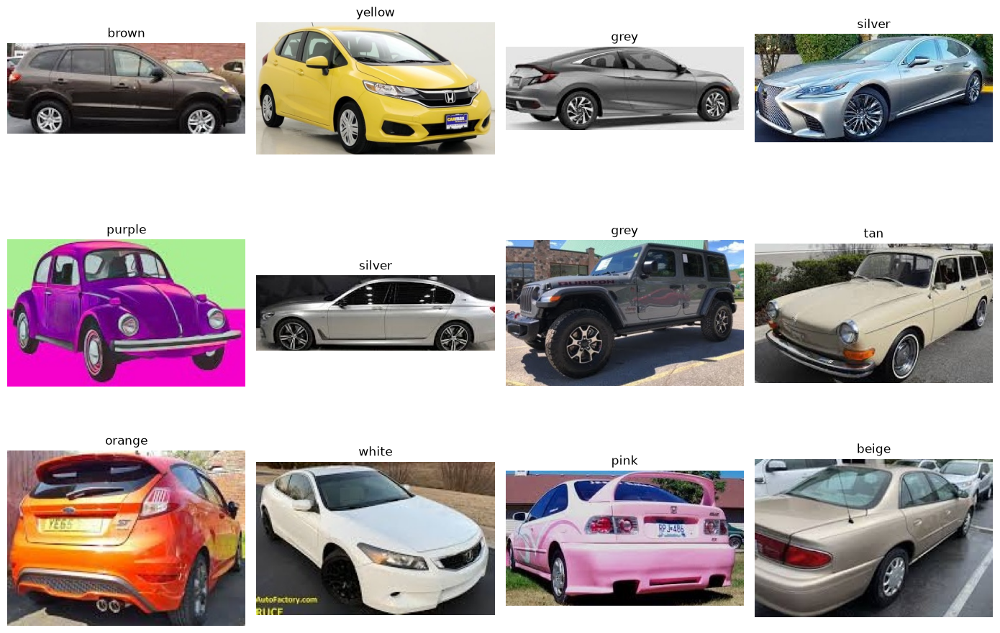

In [47]:
import matplotlib.pyplot as plt
import random

sample_df = df.sample(
    min(12, len(df)),
    random_state=42
)

plt.figure(figsize=(14, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
class_names = sorted(df["label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(class_names)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

df["label_id"] = df["label"].map(label_to_id)

print("Class mapping:")
for idx, label in id_to_label.items():
    print(idx, "→", label)

Class mapping:
0 → beige
1 → black
2 → blue
3 → brown
4 → gold
5 → green
6 → grey
7 → orange
8 → pink
9 → purple
10 → raw
11 → red
12 → silver
13 → tan
14 → white
15 → yellow


In [50]:
raw_images = df[df["label"] == "raw"]

print("Raw images:", len(raw_images))
print(raw_images["image_path"].to_string(index=False))

Raw images: 1
c:\Users\hasibul shaikh\Documents\Car_Color_Det...


In [51]:
df = df[df["label"] != "raw"].copy()

print("Remaining images:", len(df))
print("\nClasses:")
print(df["label"].value_counts())

Remaining images: 10373

Classes:
label
blue      1060
red        909
yellow     824
brown      807
green      804
purple     765
orange     762
pink       689
grey       611
beige      601
black      579
white      575
tan        571
silver     516
gold       300
Name: count, dtype: int64


In [52]:
class_names = sorted(df["label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(class_names)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

df["label_id"] = df["label"].map(label_to_id)

print("Class mapping:")
for idx, label in id_to_label.items():
    print(idx, "→", label)

Class mapping:
0 → beige
1 → black
2 → blue
3 → brown
4 → gold
5 → green
6 → grey
7 → orange
8 → pink
9 → purple
10 → red
11 → silver
12 → tan
13 → white
14 → yellow


In [53]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_id"],
    random_state=42
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Total      :", len(df))
print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))

Total      : 10373
Training   : 7261
Validation : 1556
Testing    : 1556


In [54]:
print("=== TRAIN ===")
print(train_df["label"].value_counts().sort_index())

print("\n=== VALIDATION ===")
print(val_df["label"].value_counts().sort_index())

print("\n=== TEST ===")
print(test_df["label"].value_counts().sort_index())

=== TRAIN ===
label
beige     421
black     405
blue      742
brown     565
gold      210
green     563
grey      428
orange    533
pink      482
purple    535
red       636
silver    361
tan       400
white     403
yellow    577
Name: count, dtype: int64

=== VALIDATION ===
label
beige      90
black      87
blue      159
brown     121
gold       45
green     120
grey       92
orange    115
pink      104
purple    115
red       136
silver     77
tan        86
white      86
yellow    123
Name: count, dtype: int64

=== TEST ===
label
beige      90
black      87
blue      159
brown     121
gold       45
green     121
grey       91
orange    114
pink      103
purple    115
red       137
silver     78
tan        85
white      86
yellow    124
Name: count, dtype: int64


In [55]:
print("=== TRAIN ===")
print(train_df["label"].value_counts().sort_index())

print("\n=== VALIDATION ===")
print(val_df["label"].value_counts().sort_index())

print("\n=== TEST ===")
print(test_df["label"].value_counts().sort_index())

=== TRAIN ===
label
beige     421
black     405
blue      742
brown     565
gold      210
green     563
grey      428
orange    533
pink      482
purple    535
red       636
silver    361
tan       400
white     403
yellow    577
Name: count, dtype: int64

=== VALIDATION ===
label
beige      90
black      87
blue      159
brown     121
gold       45
green     120
grey       92
orange    115
pink      104
purple    115
red       136
silver     77
tan        86
white      86
yellow    123
Name: count, dtype: int64

=== TEST ===
label
beige      90
black      87
blue      159
brown     121
gold       45
green     121
grey       91
orange    114
pink      103
purple    115
red       137
silver     78
tan        85
white      86
yellow    124
Name: count, dtype: int64


In [56]:
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test      :", len(train_paths & test_paths))
print("Validation ∩ Test :", len(val_paths & test_paths))

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


In [57]:
split_dir = PROJECT_DIR /"Car_Color_Detection_AI"/ "data" / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

In [58]:
train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "validation.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Dataset splits saved successfully.")

Dataset splits saved successfully.


In [59]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [60]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

Image size: (224, 224)
Batch size: 32
Number of classes: 15
Classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']


In [61]:
import tensorflow as tf

train_data = pd.read_csv(split_dir / "train.csv")
val_data = pd.read_csv(split_dir / "validation.csv")
test_data = pd.read_csv(split_dir / "test.csv")

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 7261
Validation: 1556
Test: 1556


In [62]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

In [63]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_data["image_path"].values,
        train_data["label_id"].values
    )
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [64]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_data["image_path"].values,
        val_data["label_id"].values
    )
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [65]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_data["image_path"].values,
        test_data["label_id"].values
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

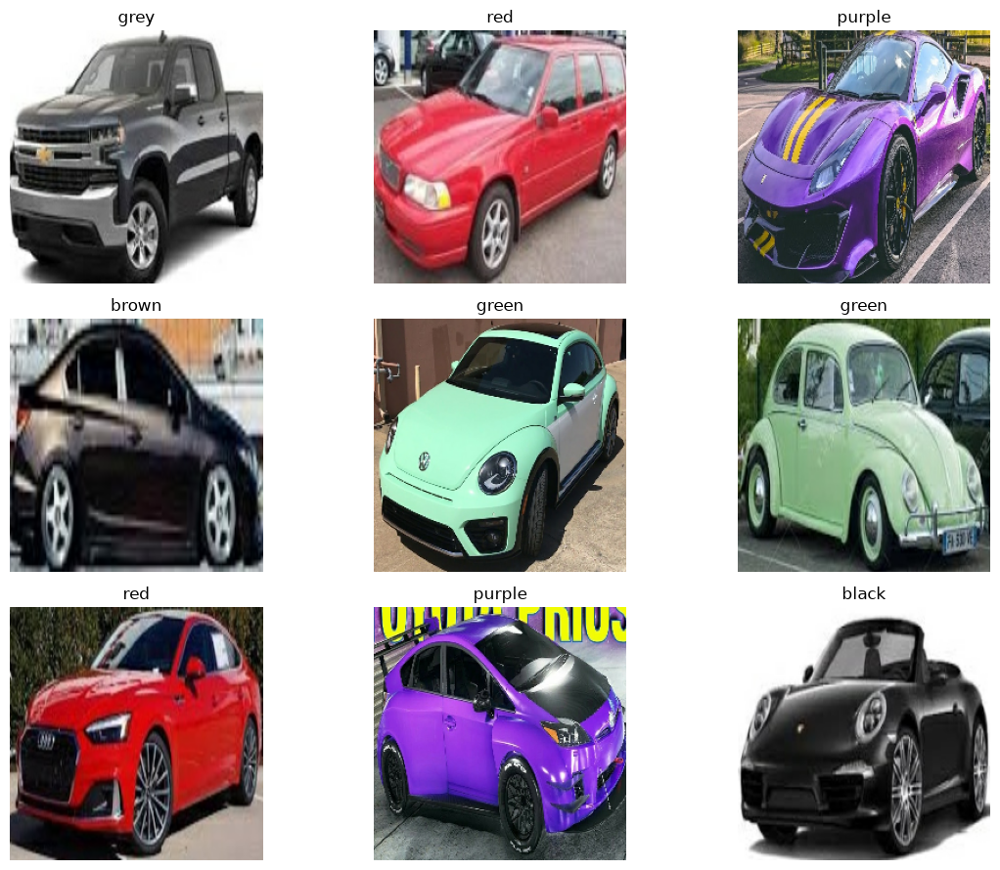

In [66]:
import matplotlib.pyplot as plt

images_batch, labels_batch = next(iter(train_ds))

plt.figure(figsize=(12, 9))

for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(images_batch[i].numpy())
    
    label_id = int(labels_batch[i].numpy())
    label = id_to_label[label_id]
    
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    
    # Input
    layers.Input(shape=(224, 224, 3)),
    
    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Classification
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,711 (37.50 MB)

 Trainable params: 9,829,711 (37.50 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [69]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_dir = PROJECT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    
    ModelCheckpoint(
        filepath=str(model_dir / "car_color_best.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [70]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30


c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


227/227 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.4930 - loss: 1.4796 - val_accuracy: 0.6594 - val_loss: 0.9240
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 219s 958ms/step - accuracy: 0.6655 - loss: 0.9549 - val_accuracy: 0.7339 - val_loss: 0.7591
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 201s 882ms/step - accuracy: 0.7152 - loss: 0.8100 - val_accuracy: 0.7776 - val_loss: 0.6227
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 203s 891ms/step - accuracy: 0.7493 - loss: 0.7175 - val_accuracy: 0.7384 - val_loss: 0.7234
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 205s 899ms/step - accuracy: 0.7499 - loss: 0.7068 - val_accuracy: 0.7629 - val_loss: 0.6690
Epoch 6/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 205s 899ms/step - accuracy: 0.7828 - loss: 0.6230 - val_accuracy: 0.7693 - val_loss: 0.6437
Epoch 7/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 224s 982ms/step - accuracy: 0.8072 - loss: 0.5378 - val_accuracy: 0.7706 - val_loss: 0.6481
Epoch 8/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 212s 928ms/step - accuracy: 0.8233 - loss: 0.5050 

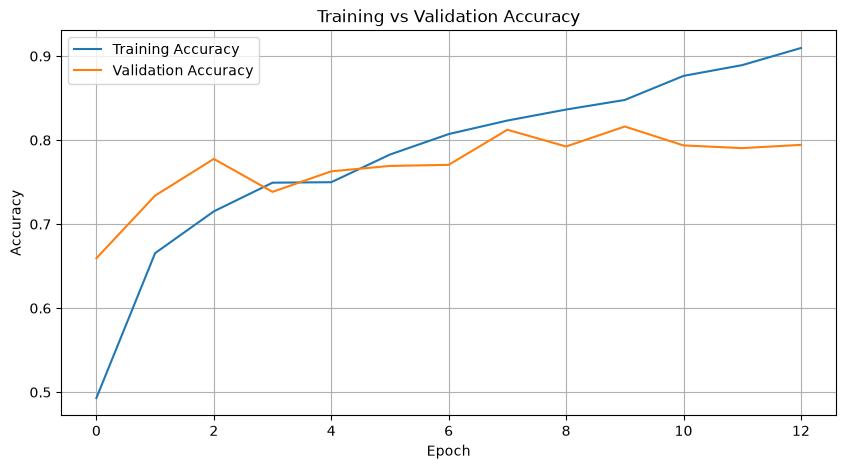

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

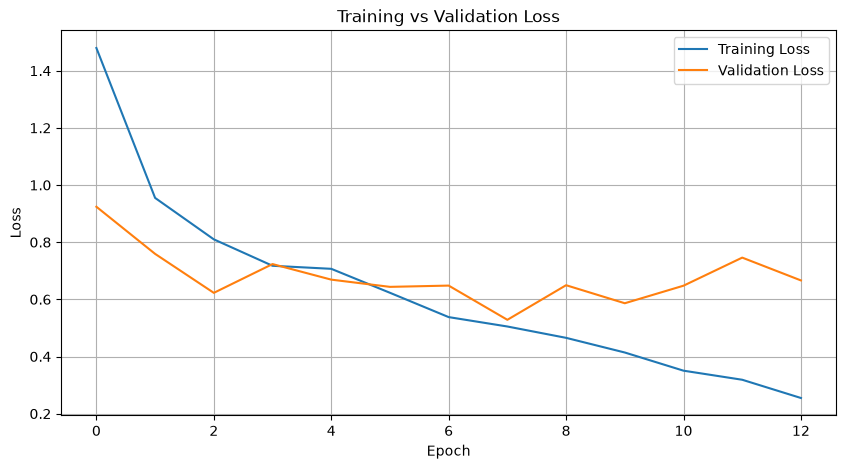

In [72]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - accuracy: 0.7898 - loss: 0.6139
Test Loss: 0.6139418482780457
Test Accuracy: 0.7898457646369934


In [74]:
from pathlib import Path

# Exact project models folder
model_dir = Path(r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\models")

# Create folder if it doesn't exist
model_dir.mkdir(parents=True, exist_ok=True)

# Final model path
final_model_path = model_dir / "car_color_model.keras"

# Save model
model.save(final_model_path)

print("✅ Model saved at:")
print(final_model_path)

✅ Model saved at:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\models\car_color_model.keras


In [75]:
import numpy as np

y_true = []
y_pred = []

for images_batch, labels_batch in test_ds:
    predictions = model.predict(images_batch, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test samples:", len(y_true))

Total test samples: 1556


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       beige     0.4894    0.2556    0.3358        90
       black     0.7103    0.8736    0.7835        87
        blue     0.9806    0.9560    0.9682       159
       brown     0.7059    0.7934    0.7471       121
        gold     0.3871    0.2667    0.3158        45
       green     0.9652    0.9174    0.9407       121
        grey     0.6712    0.5385    0.5976        91
      orange     0.8559    0.8860    0.8707       114
        pink     0.8661    0.9417    0.9023       103
      purple     0.9811    0.9043    0.9412       115
         red     0.8836    0.9416    0.9117       137
      silver     0.6023    0.6795    0.6386        78
         tan     0.4000    0.4941    0.4421        85
       white     0.9538    0.7209    0.8212        86
      yellow     0.8026    0.9839    0.8841       124

    accuracy                         0.7898      1556
   macro avg     0.7503    0.7435    0.7400      1556
weighted avg     0.7877   

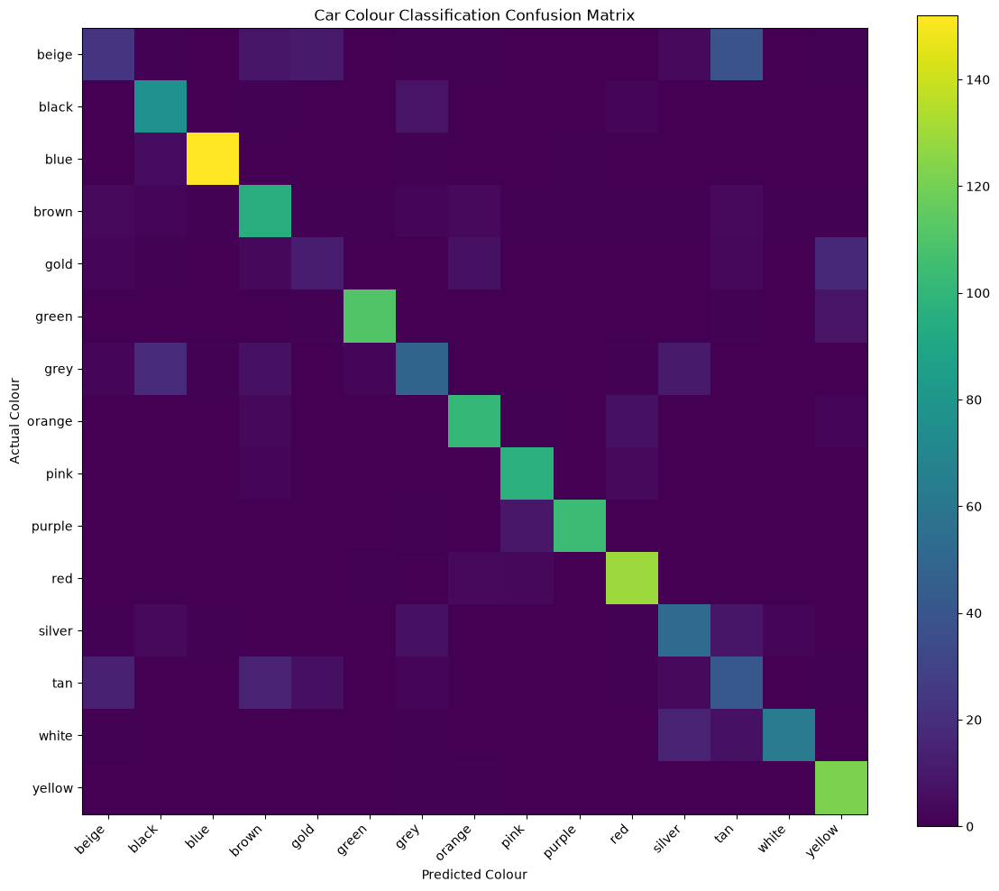

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Colour")
plt.ylabel("Actual Colour")
plt.title("Car Colour Classification Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [78]:
def predict_car_color(image_path):
    img = Image.open(image_path).convert("RGB")
    
    resized = img.resize(IMG_SIZE)
    
    image_array = np.array(resized, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)
    
    probabilities = model.predict(image_array, verbose=0)[0]
    
    predicted_id = np.argmax(probabilities)
    predicted_label = id_to_label[predicted_id]
    confidence = probabilities[predicted_id]
    
    return predicted_label, confidence

In [79]:
sample_path = test_data.iloc[0]["image_path"]

predicted_label, confidence = predict_car_color(sample_path)

print("Image:", sample_path)
print("Actual:", test_data.iloc[0]["label"])
print("Predicted:", predicted_label)
print("Confidence:", f"{confidence * 100:.2f}%")

Image: c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\archive (6)\train\purple\b7573a918d.jpg
Actual: purple
Predicted: pink
Confidence: 99.06%


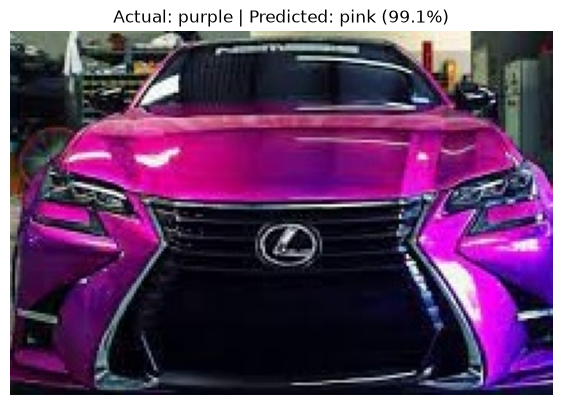

In [80]:
plt.figure(figsize=(7, 5))

img = Image.open(sample_path).convert("RGB")

plt.imshow(img)

plt.title(
    f"Actual: {test_data.iloc[0]['label']} | "
    f"Predicted: {predicted_label} "
    f"({confidence * 100:.1f}%)"
)

plt.axis("off")
plt.show()

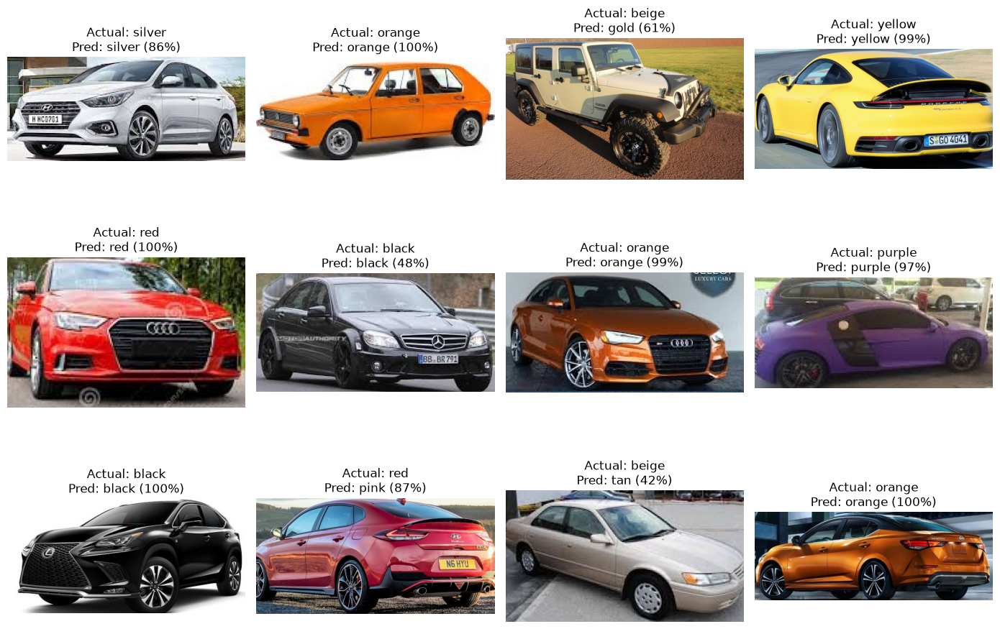

In [81]:
sample_test = test_data.sample(
    min(12, len(test_data)),
    random_state=42
)

plt.figure(figsize=(14, 10))

for i, (_, row) in enumerate(sample_test.iterrows()):
    
    predicted_label, confidence = predict_car_color(
        row["image_path"]
    )
    
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    
    plt.title(
        f"Actual: {row['label']}\n"
        f"Pred: {predicted_label} "
        f"({confidence * 100:.0f}%)"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
import sys
from pathlib import Path

# Add the src folder to Python's import path
PROJECT_DIR = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI"
)

sys.path.insert(
    0,
    str(PROJECT_DIR / "src")
)

from shade_detector import CarShadeDetector

print("CarShadeDetector imported successfully!")

CarShadeDetector imported successfully!


In [3]:
import cv2

traffic_image_path = (
    PROJECT_DIR / "data" / "raw" / "traffic_test.jpg"
)

image = cv2.imread(str(traffic_image_path))

if image is None:
    print("Image not found. Check the image path.")
else:
    print("Image loaded successfully!")
    print("Image dimensions:", image.shape)

Image loaded successfully!
Image dimensions: (6960, 4640, 3)


In [4]:
shade_detector = CarShadeDetector()

print("Shade detector initialized!")
print("Number of shades:", len(shade_detector.shade_palette))

Shade detector initialized!
Number of shades: 55


In [5]:
shade_result = shade_detector.predict(image)

print("=" * 45)
print("CAR SHADE DETECTION RESULT")
print("=" * 45)

print("Shade:", shade_result["shade"])
print("HEX:", shade_result["hex"])
print("RGB:", shade_result["rgb"])
print("Similarity:", shade_result["similarity"], "%")
print("Dominant RGB:", shade_result["dominant_rgb"])

CAR SHADE DETECTION RESULT
Shade: Dark Purple
HEX: #252B2E
RGB: (37, 43, 46)
Similarity: 95.16 %
Dominant RGB: (37, 43, 46)


In [6]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your existing YOLO model
vehicle_model = YOLO(
    str(PROJECT_DIR / "yolo11n.pt")
)

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [7]:
results = vehicle_model.predict(
    source=str(traffic_image_path),
    imgsz=960,
    conf=0.25,
    verbose=False
)

result = results[0]

print("Detection completed!")
print("Total detected objects:", len(result.boxes))

Detection completed!
Total detected objects: 19


In [8]:
car_crops = []

for box in result.boxes:

    class_id = int(box.cls[0])

    # COCO class 2 = car
    if class_id != 2:
        continue

    x1, y1, x2, y2 = map(
        int,
        box.xyxy[0].tolist()
    )

    # Keep coordinates within image boundaries
    h, w = image.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    car_crops.append(crop)

print("Cars detected:", len(car_crops))

Cars detected: 7


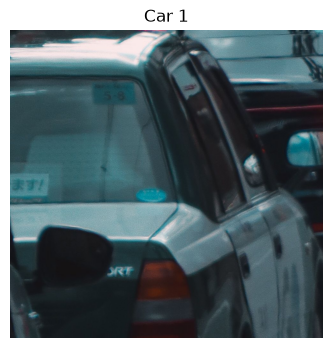

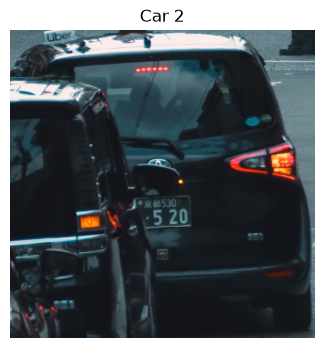

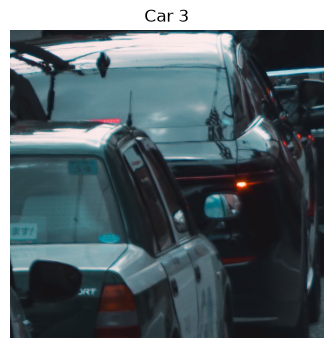

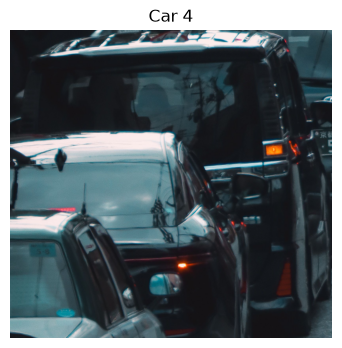

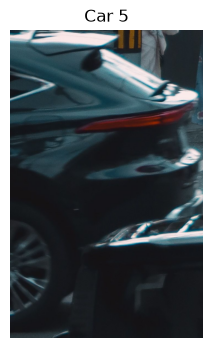

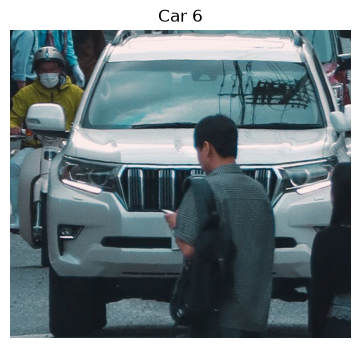

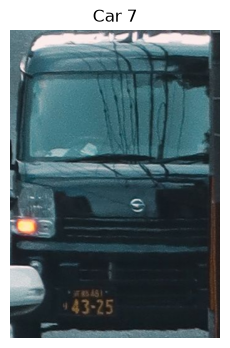

In [9]:
if len(car_crops) == 0:
    print("No cars detected. Try adjusting the confidence threshold.")
else:
    for i, crop in enumerate(car_crops):

        plt.figure(figsize=(6, 4))

        plt.imshow(
            cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        )

        plt.title(f"Car {i + 1}")
        plt.axis("off")
        plt.show()

In [10]:
print("Total detected objects:", len(result.boxes))
print("Total car crops:", len(car_crops))


Total detected objects: 19
Total car crops: 7


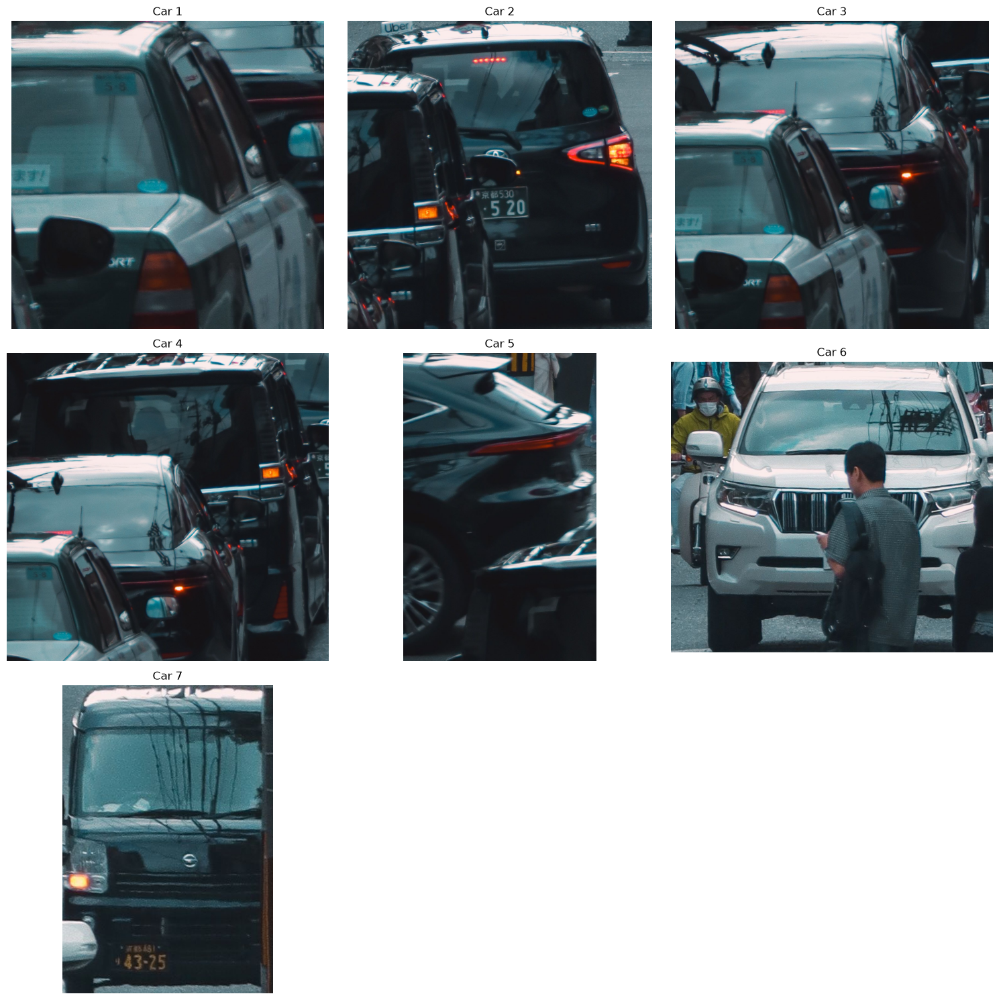

In [11]:
import matplotlib.pyplot as plt
import cv2
import math

num_cars = len(car_crops)

cols = 3
rows = math.ceil(num_cars / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, 5 * rows)
)

axes = axes.flatten()

for i, crop in enumerate(car_crops):

    rgb_crop = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(rgb_crop)
    axes[i].set_title(f"Car {i + 1}")
    axes[i].axis("off")

# Hide unused plots
for j in range(num_cars, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [12]:
for i, crop in enumerate(car_crops):

    result = shade_detector.predict(crop)

    print("=" * 45)
    print(f"CAR {i + 1}")
    print("=" * 45)

    print("Shade:", result["shade"])
    print("HEX:", result["hex"])
    print("RGB:", result["rgb"])
    print("Similarity:", result["similarity"], "%")

CAR 1
Shade: Dark Purple
HEX: #1F2428
RGB: (31, 36, 40)
Similarity: 94.63 %
CAR 2
Shade: Dark Purple
HEX: #1A2126
RGB: (26, 33, 38)
Similarity: 93.93 %
CAR 3
Shade: Dark Purple
HEX: #1F2529
RGB: (31, 37, 41)
Similarity: 94.76 %
CAR 4
Shade: Dark Purple
HEX: #1D2228
RGB: (29, 34, 40)
Similarity: 94.37 %
CAR 5
Shade: Dark Purple
HEX: #191D21
RGB: (25, 29, 33)
Similarity: 93.23 %
CAR 6
Shade: Dark Purple
HEX: #242F33
RGB: (36, 47, 51)
Similarity: 94.39 %
CAR 7
Shade: Dark Purple
HEX: #1F2A2F
RGB: (31, 42, 47)
Similarity: 94.39 %


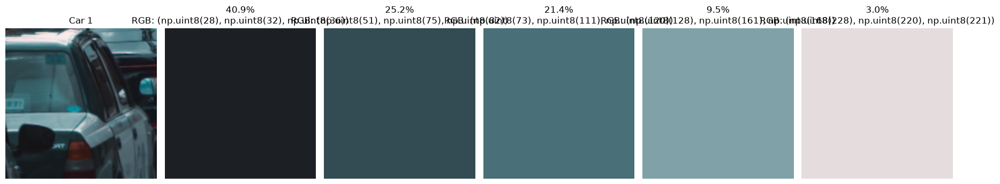

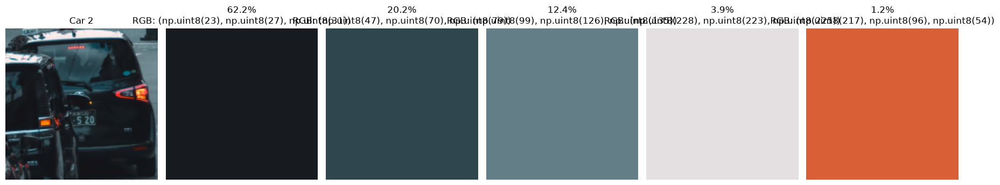

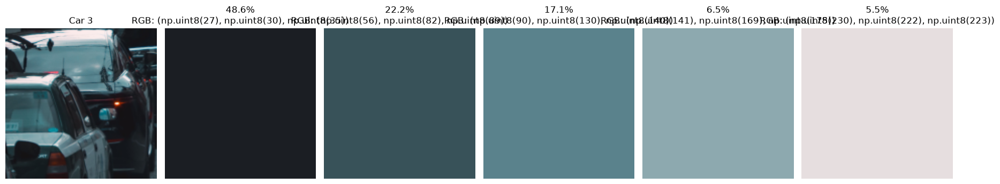

In [13]:

import cv2
import numpy as np
import matplotlib.pyplot as plt


def visualize_car_color_clusters(image, car_number, k=5):

    # Resize image
    resized = cv2.resize(
        image,
        (150, 150),
        interpolation=cv2.INTER_AREA
    )

    # Convert BGR to RGB
    rgb = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2RGB
    )

    pixels = rgb.reshape(-1, 3).astype(np.float32)

    # K-Means criteria
    criteria = (
        cv2.TERM_CRITERIA_EPS
        + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    # Cluster pixels
    _, labels, centers = cv2.kmeans(
        pixels,
        k,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS
    )

    # Count cluster pixels
    counts = np.bincount(
        labels.flatten(),
        minlength=k
    )

    percentages = counts / counts.sum() * 100

    # Sort clusters by frequency
    order = np.argsort(counts)[::-1]

    fig, axes = plt.subplots(
        1,
        k + 1,
        figsize=(18, 4)
    )

    # Original crop
    axes[0].imshow(rgb)
    axes[0].set_title(f"Car {car_number}")
    axes[0].axis("off")

    # Display clusters
    for i, cluster_id in enumerate(order):

        color = np.clip(
            centers[cluster_id],
            0,
            255
        ).astype(np.uint8)

        axes[i + 1].imshow(
            np.full((100, 100, 3), color, dtype=np.uint8)
        )

        axes[i + 1].set_title(
            f"{percentages[cluster_id]:.1f}%\n"
            f"RGB: {tuple(color)}"
        )

        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


# Test the first three cars
for i in range(min(3, len(car_crops))):

    visualize_car_color_clusters(
        car_crops[i],
        i + 1
    )


In [15]:
import sys
from pathlib import Path

# Set your project root directory
PROJECT_DIR = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI"
)

# Add project root to Python's import path
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project directory:", PROJECT_DIR)
print("Directory exists:", PROJECT_DIR.exists())
print("Source folder exists:", (PROJECT_DIR / "src").exists())

Project directory: C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI
Directory exists: True
Source folder exists: True


In [16]:
from src.gradient_analyzer import CarGradientAnalyzer

analyzer = CarGradientAnalyzer(number_of_colors=4)

print("Gradient analyzer imported successfully!")

Gradient analyzer imported successfully!


In [24]:
from pathlib import Path

RAW_DIR = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw"
)

print("Folders and files inside data/raw:\n")

for item in RAW_DIR.iterdir():
    if item.is_dir():
        print("[FOLDER]", item.name)
    else:
        print("[FILE]", item.name)

Folders and files inside data/raw:

[FOLDER] archive (6)
[FILE] pexels-imadseyes-12658597.jpg
[FILE] pexels-introspectivedsgn-5516033.jpg
[FILE] pexels-junnoet-235226.jpg
[FILE] pexels-kraken-media-392419767-17145721.jpg
[FILE] pexels-michael-obstoj-1772571864-31867049.jpg
[FILE] pexels-nihatkasikci-6647721.jpg
[FILE] pexels-skylake-18775760.jpg
[FILE] pexels-unpoquitodefoto-17895682.jpg
[FILE] pexels-vinicius-quaresma-511530024-18103945.jpg
[FILE] traffic_test.jpg


In [ ]:
import cv2
from pathlib import Path
from IPython.display import display
from PIL import Image

image_path = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\pexels-imadseyes-12658597.jpg"
)

image = cv2.imread(str(image_path))

if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Dimensions:", image.shape)

    display(Image.open(image_path))

Image loaded successfully!
Dimensions: (5184, 3456, 3)
